# Analyse Statistique Approfondie - Dataset Pneumonie

Dataset: [Pneumonia Radiography Dataset - Kaggle](https://www.kaggle.com/datasets/iamtanmayshukla/pneumonia-radiography-dataset)

Analyses statistiques avancees pour comprendre les caracteristiques du dataset

**Note:** Le dataset se télécharge automatiquement via kagglehub lors de la première exécution.

In [1]:
import sys
sys.path.append('..')

from src.data_loader import load_raw_pneumonia_dataset
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import scipy.stats as stats
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

/Users/taoufik/CLassification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Charger le dataset
dataset = load_raw_pneumonia_dataset("train")
print(f"Dataset: {len(dataset)} images")

labels = dataset['label']
class_counts = Counter(labels)
print(f"Classe 0 (Sain): {class_counts[0]}")
print(f"Classe 1 (Pneumonie): {class_counts[1]}")

Dataset: 5232 images
Classe 0 (Sain): 1349
Classe 1 (Pneumonie): 3883


## 1. Statistiques des Dimensions

In [3]:
# Analyser dimensions sur 200 images
sample_size = min(200, len(dataset))
sample_images = [dataset[i]['image'] for i in range(sample_size)]
dimensions = [img.size for img in sample_images]

widths = [d[0] for d in dimensions]
heights = [d[1] for d in dimensions]

print("=== STATISTIQUES DES DIMENSIONS ===")
print(f"Largeur moyenne: {np.mean(widths):.2f} px (ecart-type: {np.std(widths):.2f})")
print(f"Hauteur moyenne: {np.mean(heights):.2f} px (ecart-type: {np.std(heights):.2f})")
print(f"\nLargeur: min={min(widths)}, max={max(widths)}, mediane={np.median(widths):.0f}")
print(f"Hauteur: min={min(heights)}, max={max(heights)}, mediane={np.median(heights):.0f}")
print(f"\nRatio moyen (largeur/hauteur): {np.mean([w/h for w,h in zip(widths, heights)]):.2f}")

=== STATISTIQUES DES DIMENSIONS ===
Largeur moyenne: 1685.51 px (ecart-type: 273.01)
Hauteur moyenne: 1401.47 px (ecart-type: 308.50)

Largeur: min=1056, max=2844, mediane=1666
Hauteur: min=792, max=2628, mediane=1366

Ratio moyen (largeur/hauteur): 1.22


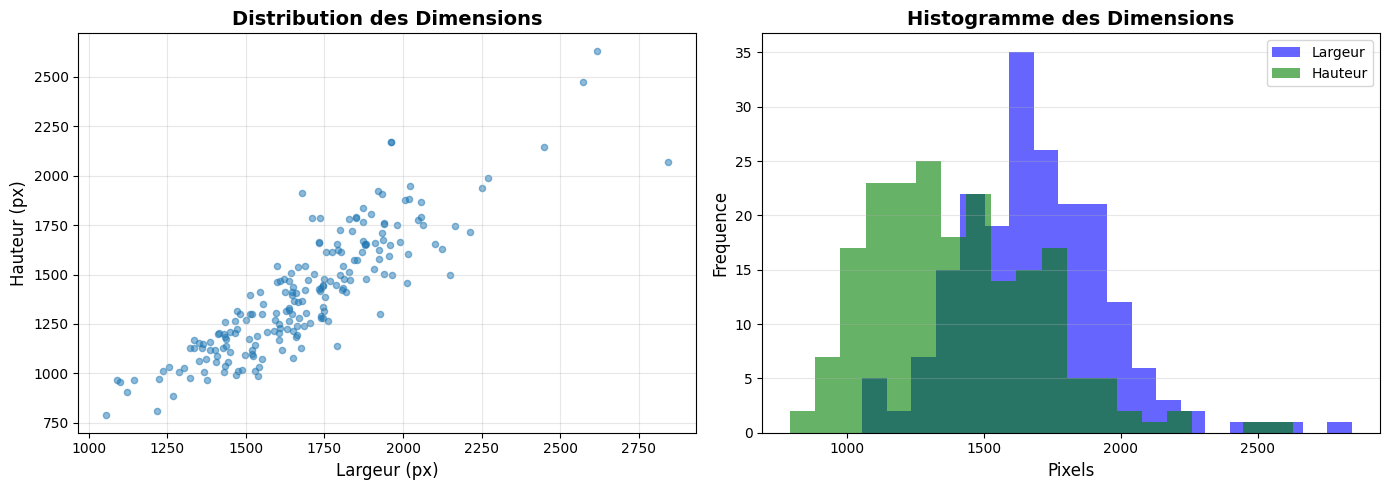

In [4]:
# Visualisation des dimensions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot dimensions
axes[0].scatter(widths, heights, alpha=0.5, s=20)
axes[0].set_xlabel('Largeur (px)', fontsize=12)
axes[0].set_ylabel('Hauteur (px)', fontsize=12)
axes[0].set_title('Distribution des Dimensions', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Histogrammes
axes[1].hist(widths, bins=20, alpha=0.6, label='Largeur', color='blue')
axes[1].hist(heights, bins=20, alpha=0.6, label='Hauteur', color='green')
axes[1].set_xlabel('Pixels', fontsize=12)
axes[1].set_ylabel('Frequence', fontsize=12)
axes[1].set_title('Histogramme des Dimensions', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Analyse de l'Intensite des Pixels

In [5]:
# Extraire indices par classe
healthy_indices = [i for i, label in enumerate(dataset['label']) if label == 0][:100]
pneumo_indices = [i for i, label in enumerate(dataset['label']) if label == 1][:100]

print("Calcul des intensites sur 100 images par classe...")

healthy_intensities = []
pneumonia_intensities = []

for idx in healthy_indices:
    img_array = np.array(dataset[idx]['image'])
    healthy_intensities.append(img_array.mean())

for idx in pneumo_indices:
    img_array = np.array(dataset[idx]['image'])
    pneumonia_intensities.append(img_array.mean())

print("\n=== STATISTIQUES INTENSITE ===")
print(f"Sain: moyenne={np.mean(healthy_intensities):.2f}, std={np.std(healthy_intensities):.2f}")
print(f"Pneumonie: moyenne={np.mean(pneumonia_intensities):.2f}, std={np.std(pneumonia_intensities):.2f}")

Calcul des intensites sur 100 images par classe...

=== STATISTIQUES INTENSITE ===
Sain: moyenne=119.48, std=14.31
Pneumonie: moyenne=124.77, std=18.91


In [6]:
# Test statistique t-test
t_stat, p_value = stats.ttest_ind(healthy_intensities, pneumonia_intensities)

print("=== TEST T DE STUDENT ===")
print(f"Hypothese H0: Les deux classes ont la meme intensite moyenne")
print(f"Statistique t: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"\nConclusion:")
if p_value < 0.05:
    print(f"  - Difference SIGNIFICATIVE entre les classes (p={p_value:.6f} < 0.05)")
    print(f"  - Le modele pourra apprendre cette difference")
else:
    print(f"  - Pas de difference significative (p={p_value:.6f} >= 0.05)")
    print(f"  - Les intensites seules ne suffiront pas")

=== TEST T DE STUDENT ===
Hypothese H0: Les deux classes ont la meme intensite moyenne
Statistique t: -2.2227
P-value: 0.027371

Conclusion:
  - Difference SIGNIFICATIVE entre les classes (p=0.027371 < 0.05)
  - Le modele pourra apprendre cette difference


/var/folders/57/w57rmyhn4ks_c2f5cqz8lcd40000gn/T/ipykernel_13457/3018906190.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_to_plot, labels=['Sain', 'Pneumonie'],


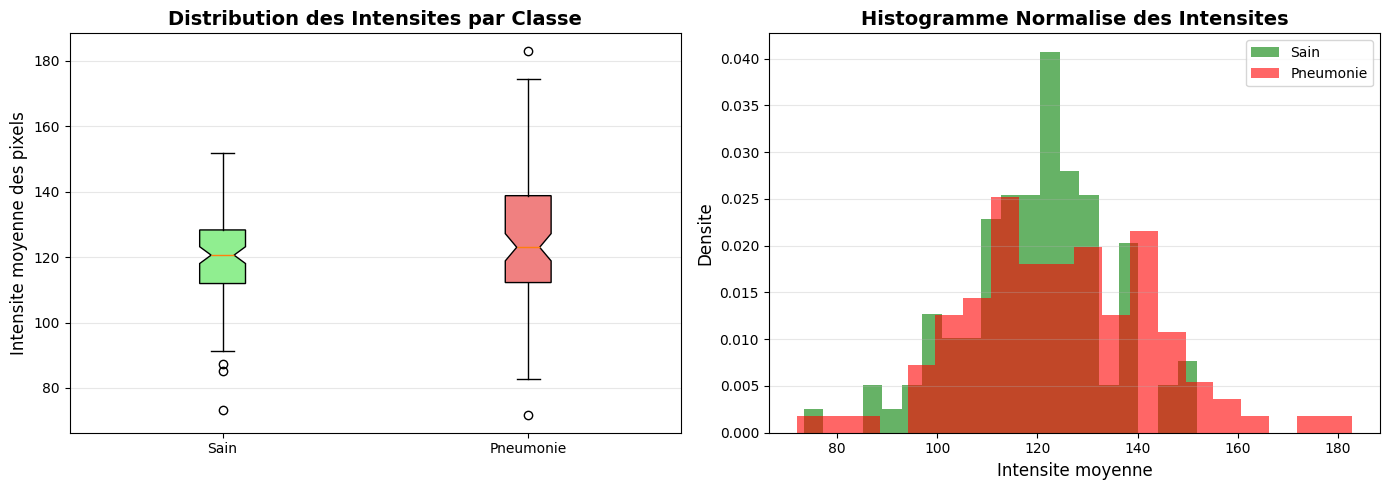

In [7]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
data_to_plot = [healthy_intensities, pneumonia_intensities]
bp = axes[0].boxplot(data_to_plot, labels=['Sain', 'Pneumonie'],
                     patch_artist=True, notch=True)
colors = ['lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('Intensite moyenne des pixels', fontsize=12)
axes[0].set_title('Distribution des Intensites par Classe', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Histogrammes superposes
axes[1].hist(healthy_intensities, bins=20, alpha=0.6, label='Sain', color='green', density=True)
axes[1].hist(pneumonia_intensities, bins=20, alpha=0.6, label='Pneumonie', color='red', density=True)
axes[1].set_xlabel('Intensite moyenne', fontsize=12)
axes[1].set_ylabel('Densite', fontsize=12)
axes[1].set_title('Histogramme Normalise des Intensites', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Test Chi-Square pour Equilibre des Classes

In [8]:
print("=== TEST CHI-SQUARE POUR EQUILIBRE ===")
observed = [class_counts[0], class_counts[1]]
expected_equal = [len(dataset)/2, len(dataset)/2]

chi2, p_chi = stats.chisquare(observed, expected_equal)

print(f"Observations:")
print(f"  - Sain: {observed[0]} ({observed[0]/len(dataset)*100:.1f}%)")
print(f"  - Pneumonie: {observed[1]} ({observed[1]/len(dataset)*100:.1f}%)")
print(f"\nAttendu (equilibre parfait): {expected_equal[0]:.0f} (50%) pour chaque classe")
print(f"\nChi-square: {chi2:.2f}")
print(f"P-value: {p_chi:.10f}")

print(f"\nConclusion:")
if p_chi < 0.05:
    print(f"  - Desequilibre SIGNIFICATIF (p < 0.05)")
    print(f"  - Recommandation: Utiliser class_weight dans la loss ou data augmentation")
    ratio = max(observed) / min(observed)
    print(f"  - Ratio de desequilibre: {ratio:.2f}:1")
else:
    print(f"  - Classes equilibrees")

=== TEST CHI-SQUARE POUR EQUILIBRE ===
Observations:
  - Sain: 1349 (25.8%)
  - Pneumonie: 3883 (74.2%)

Attendu (equilibre parfait): 2616 (50%) pour chaque classe

Chi-square: 1227.29
P-value: 0.0000000000

Conclusion:
  - Desequilibre SIGNIFICATIF (p < 0.05)
  - Recommandation: Utiliser class_weight dans la loss ou data augmentation
  - Ratio de desequilibre: 2.88:1


## 4. Calcul des Class Weights

In [9]:
# Calculer les poids pour compenser le desequilibre
class_labels = np.array([0, 1])
weights = compute_class_weight('balanced', classes=class_labels, y=dataset['label'])

weights_dict = {0: weights[0], 1: weights[1]}

print("=== POIDS DES CLASSES POUR L'ENTRAINEMENT ===")
print(f"\nPoids a utiliser dans PyTorch:")
print(f"  - Classe 0 (Sain): {weights[0]:.4f}")
print(f"  - Classe 1 (Pneumonie): {weights[1]:.4f}")
print(f"\nRatio: La classe minoritaire a un poids {weights[0]/weights[1]:.2f}x plus eleve")
print(f"\nCode PyTorch:")
print(f"  class_weights = torch.FloatTensor([{weights[0]:.4f}, {weights[1]:.4f}])")
print(f"  criterion = nn.CrossEntropyLoss(weight=class_weights)")

=== POIDS DES CLASSES POUR L'ENTRAINEMENT ===

Poids a utiliser dans PyTorch:
  - Classe 0 (Sain): 1.9392
  - Classe 1 (Pneumonie): 0.6737

Ratio: La classe minoritaire a un poids 2.88x plus eleve

Code PyTorch:
  class_weights = torch.FloatTensor([1.9392, 0.6737])
  criterion = nn.CrossEntropyLoss(weight=class_weights)


## 5. Resume des Recommandations

**Preprocessing requis:**
- Redimensionner toutes les images a 224x224 (standard ResNet)
- Convertir en 3 canaux (RGB) pour ResNet pre-entraine
- Normaliser avec ImageNet stats: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

**Gestion du desequilibre:**
- Utiliser class_weights dans la loss function
- Ou appliquer data augmentation sur classe minoritaire (Sain)
- Ou utiliser focal loss

**Metriques d'evaluation:**
- Accuracy (attention au desequilibre)
- Recall (sensibilite) - CRITIQUE pour detecter pneumonie
- Precision - eviter faux positifs
- F1-Score
- ROC-AUC
- Confusion Matrix